In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

In [ ]:
from sklearn.preprocessing import QuantileTransformer
from sklearn import linear_model


def _gauss_transform(x: np.ndarray):
    """Transform x to be (marginally) gaussian."""
    assert x.ndim == 2
    qt = QuantileTransformer(n_quantiles=len(x), output_distribution="normal", subsample=None)
    qt.fit(x)
    return qt.transform(x), qt


def multicam(x, x_train, y_train):
    assert x.ndim == x_train.ndim == y_train.ndim == 2
    xt_gauss, qtx = _gauss_transform(x_train)
    yt_gauss, qty = _gauss_transform(y_train)
    reg = linear_model.LinearRegression()
    reg.fit(xt_gauss, yt_gauss)

    x_gauss = qtx.transform(x)
    y_not_gauss = reg.predict(x_gauss)

    y_pred_train = reg.predict(xt_gauss)
    _, qtp = _gauss_transform(y_pred_train)
    y_gauss = qtp.transform(y_not_gauss)

    # invert y_gauss to data space based on gaussianized y_train.
    y_pred = qty.inverse_transform(y_gauss)
    return y_pred, y_gauss, y_not_gauss, x_gauss

In [3]:
from scipy.stats import norm, rankdata

def qt_uniform(x, axis: int = 0, method="ordinal"):  # default in rankdata = 'average'
    """Transform array to a uniform distribution based on ranks."""
    ranks = rankdata(x, axis=axis, method=method)
    return ranks / (ranks.shape[axis] + 1)  # excludes 0 and 1


def qt_gauss(x, axis: int = 0, method="ordinal"):
    """Transform array to a Gaussian distribution based on ranks."""
    u = qt_uniform(x, axis=axis, method=method)
    return norm.ppf(u)


def qt_gauss_base(x, x_base):
    """Gaussinize input based on another dataset."""
    # always assume second dimension is n_features.
    assert x.ndim == 2 and x_base.ndim == 2
    assert x.shape[1] == x_base.shape[1]
    n_features = x.shape[1]
    x_gauss = np.zeros_like(x) * np.nan
    for jj in range(n_features):
        x_jj = x[:, jj]
        xb_jj = np.sort(x_base[:, jj])  # required for np.interp
        xb_gauss_jj = qt_gauss(xb_jj, method="ordinal")
        x_gauss[:, jj] = np.interp(x_jj, xb_jj, xb_gauss_jj)
    return x_gauss


def qt_inverse_gauss_base(x_gauss, x_base):
    assert x_gauss.ndim == 2 and x_base.ndim == 2
    assert x_gauss.shape[1] == x_base.shape[1]
    n_features = x_gauss.shape[1]
    x_out = np.zeros_like(x_gauss) * np.nan
    for jj in range(n_features):
        xg_jj = x_gauss[:, jj]
        xb_jj = np.sort(x_base[:, jj])  # required for np.interp
        xb_gauss_jj = qt_gauss(xb_jj, method="ordinal")
        x_out[:, jj] = np.interp(xg_jj, xb_gauss_jj, xb_jj)
    return x_out

def new_multicam(x, x_train, y_train):
    assert x.ndim == x_train.ndim == y_train.ndim == 2
    xt_gauss = qt_gauss(x_train, axis=0)
    yt_gauss = qt_gauss(y_train, axis=0)

    reg = linear_model.LinearRegression()
    reg.fit(xt_gauss, yt_gauss)

    x_gauss = qt_gauss_base(x, x_train)
    y_not_gauss = reg.predict(x_gauss)

    y_pred_train = reg.predict(xt_gauss)
    y_gauss = qt_gauss_base(y_not_gauss, y_pred_train)

    # invert y_gauss to data space based on gaussianized y_train.
    y_pred = qt_inverse_gauss_base(y_gauss, y_train) 
    return y_pred, y_gauss, y_not_gauss, x_gauss


# Simple tests

In [4]:
x = np.random.randn(10_000)
y = 2 * x + 0.5 + np.random.randn(10_000)

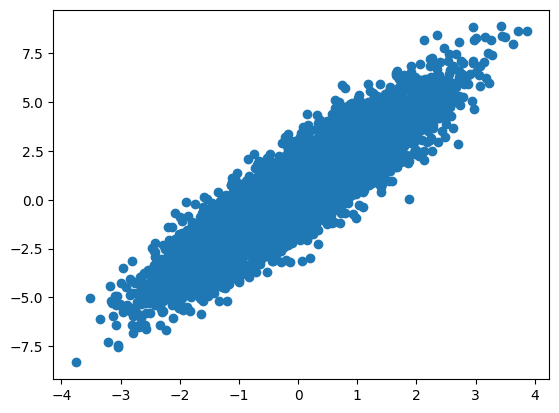

In [5]:
plt.plot(x,y, 'o')

In [6]:
from multicam.train import _get_tt_indices

train_idx, test_idx = _get_tt_indices(len(x), test_ratio=0.25)

In [7]:
x_train = x[train_idx].reshape(-1, 1)
y_train = y[train_idx].reshape(-1, 1)
x_test = x[test_idx].reshape(-1, 1)
y_test = y[test_idx].reshape(-1,1)

In [8]:
yp1, yg1, yng1, xg1 = multicam(x_test, x_train, y_train)

In [9]:
yp2, yg2, yng2, xg2 = new_multicam(x_test, x_train, y_train)

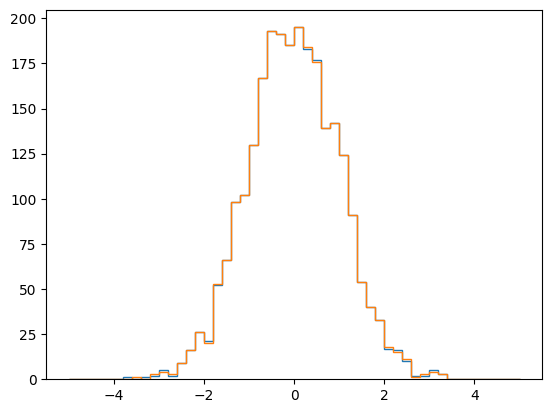

In [12]:
bins = np.linspace(-5, 5, 51)
plt.hist(xg1, histtype='step', bins=bins);
plt.hist(xg2, histtype='step', bins=bins);

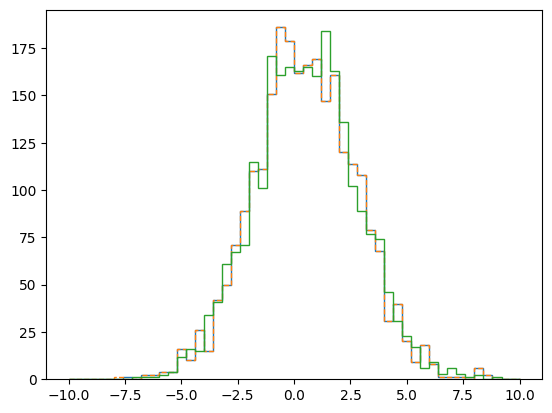

In [17]:
bins = np.linspace(-10, 10, 51)
plt.hist(yp1, bins=bins, histtype='step')
plt.hist(yp2, bins=bins, histtype='step', ls='--');
plt.hist(y_test, bins=bins, histtype='step');

In [22]:
spearmanr(yp1, y_test), spearmanr(yp2, y_test)

(SignificanceResult(statistic=np.float64(0.8855953608952578), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.8855953608952578), pvalue=np.float64(0.0)))

# 2 features

In [18]:
x = np.random.randn(10_000, 2)
y = 2 * x[:, 0] + 3 * x[:, 1] + 0.5 + np.random.randn(10_000)
x.shape, y.shape

((10000, 2), (10000,))

In [19]:
from multicam.train import _get_tt_indices

train_idx, test_idx = _get_tt_indices(x.shape[0], test_ratio=0.25)

x_train = x[train_idx]
x_test = x[test_idx]
y_train = y[train_idx].reshape(-1, 1)
y_test = y[test_idx].reshape(-1,1)

x_train.shape, x_test.shape, y_train.shape

((7500, 2), (2500, 2), (7500, 1))

In [20]:
yp1, yg1, yng1, xg1 = multicam(x_test, x_train, y_train)
yp2, yg2, yng2, xg2 = new_multicam(x_test, x_train, y_train)

In [21]:
spearmanr(yp1, y_test), spearmanr(yp2, y_test)

(SignificanceResult(statistic=np.float64(0.9609311540689848), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.960936099989776), pvalue=np.float64(0.0)))

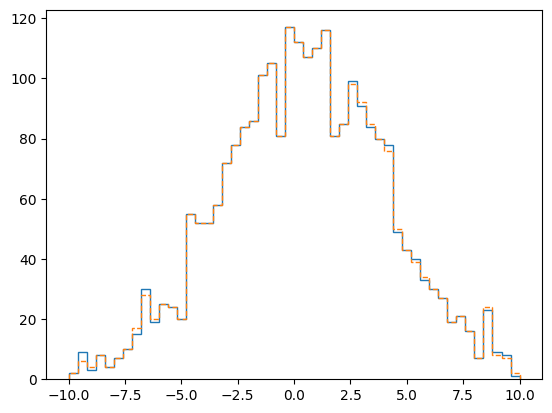

In [23]:
bins = np.linspace(-10, 10, 51)
plt.hist(yp1, bins=bins, histtype='step')
plt.hist(yp2, bins=bins, histtype='step', ls='--');
# plt.hist(y_test, bins=bins, histtype='step');

# Repeated (one) feature

In [34]:
x = np.random.randn(10_000,)
x[:2000] = 10.
y = 2 * x + 0.5 + np.random.randn(10_000)
x.shape, y.shape

((10000,), (10000,))

In [37]:
from multicam.train import _get_tt_indices

train_idx, test_idx = _get_tt_indices(x.shape[0], test_ratio=0.25)

x_train = x[train_idx].reshape(-1,1)
x_test = x[test_idx].reshape(-1,1)
y_train = y[train_idx].reshape(-1, 1)
y_test = y[test_idx].reshape(-1,1)

x_train.shape, x_test.shape, y_train.shape

((7500, 1), (2500, 1), (7500, 1))

In [38]:
yp1, yg1, yng1, xg1 = multicam(x_test, x_train, y_train)
yp2, yg2, yng2, xg2 = new_multicam(x_test, x_train, y_train)

In [39]:
spearmanr(yp1, y_test), spearmanr(yp2, y_test)

(SignificanceResult(statistic=np.float64(0.9309466804829645), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.9309466804829645), pvalue=np.float64(0.0)))

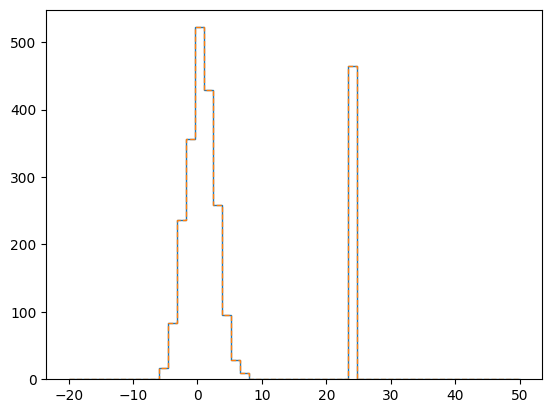

In [41]:
bins = np.linspace(-20, 50, 51)
plt.hist(yp1, bins=bins, histtype='step')
plt.hist(yp2, bins=bins, histtype='step', ls='--');
# plt.hist(y_test, bins=bins, histtype='step');

# Repeated (two) features

In [61]:
x = np.random.randn(10_000, 2)
x[:2000, 1] = 10.
y = 2 * x[:, 0] + 3 * x[:, 1] + 0.5 + np.random.randn(10_000)
x.shape, y.shape

((10000, 2), (10000,))

In [62]:
from multicam.train import _get_tt_indices

train_idx, test_idx = _get_tt_indices(x.shape[0], test_ratio=0.25)

x_train = x[train_idx]
x_test = x[test_idx]
y_train = y[train_idx].reshape(-1, 1)
y_test = y[test_idx].reshape(-1,1)

x_train.shape, x_test.shape, y_train.shape

((7500, 2), (2500, 2), (7500, 1))

In [63]:
yp1, yg1, yng1, xg1 = multicam(x_test, x_train, y_train)
yp2, yg2, yng2, xg2 = new_multicam(x_test, x_train, y_train)

In [48]:
spearmanr(yp1, y_test), spearmanr(yp2, y_test)

(SignificanceResult(statistic=np.float64(0.9356810411009667), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.9756767501920398), pvalue=np.float64(0.0)))

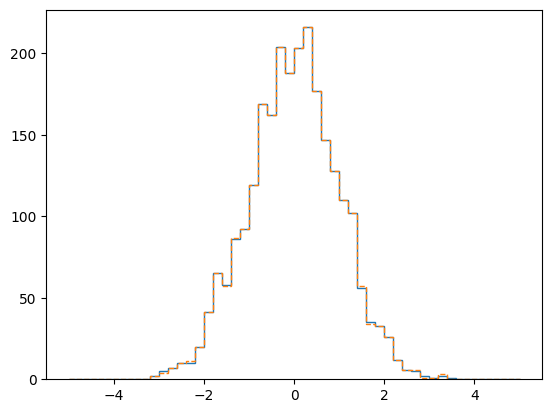

In [50]:
bins = np.linspace(-5, 5, 51)
plt.hist(xg1[:, 0], histtype='step', bins=bins);
plt.hist(xg2[:, 0], histtype='step', bins=bins, ls='--');

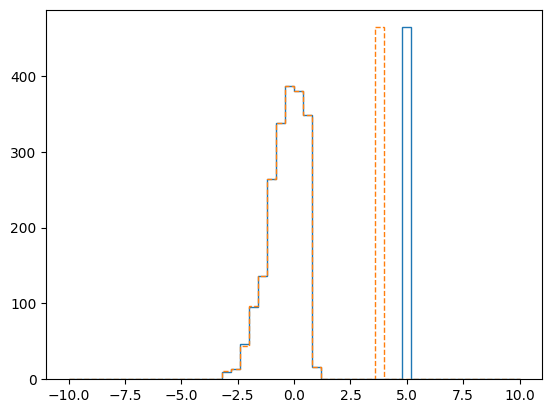

In [52]:
bins = np.linspace(-10, 10, 51)
plt.hist(xg1[:, 1], histtype='step', bins=bins);
plt.hist(xg2[:, 1], histtype='step', bins=bins, ls='--');

In [55]:
yng1.shape, yng2.shape

((2500, 1), (2500, 1))

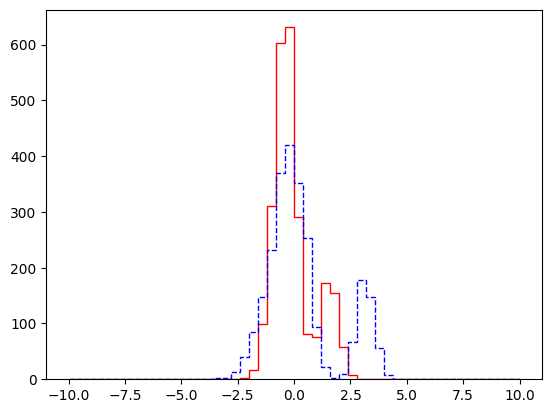

In [58]:
bins = np.linspace(-10, 10, 51)
plt.hist(yng1, histtype='step', bins=bins, color='r');
cts, _, _ = plt.hist(yng2, histtype='step', bins=bins, ls='--', color='b')

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   2.,   1.,   5.,  18.,  48.,  94., 147.,
        246., 359., 391., 333., 261., 100.,  27.,   4.,   1.,  60., 119.,
         96., 188.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.]),
 array([-10. ,  -9.6,  -9.2,  -8.8,  -8.4,  -8. ,  -7.6,  -7.2,  -6.8,
         -6.4,  -6. ,  -5.6,  -5.2,  -4.8,  -4.4,  -4. ,  -3.6,  -3.2,
         -2.8,  -2.4,  -2. ,  -1.6,  -1.2,  -0.8,  -0.4,   0. ,   0.4,
          0.8,   1.2,   1.6,   2. ,   2.4,   2.8,   3.2,   3.6,   4. ,
          4.4,   4.8,   5.2,   5.6,   6. ,   6.4,   6.8,   7.2,   7.6,
          8. ,   8.4,   8.8,   9.2,   9.6,  10. ]),
 [<matplotlib.patches.Polygon at 0x139422990>])

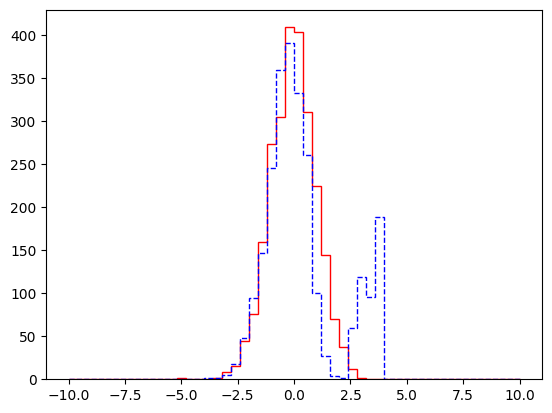

In [60]:
bins = np.linspace(-10, 10, 51)
plt.hist(yg1, histtype='step', bins=bins, color='r');
plt.hist(yg2, histtype='step', bins=bins, ls='--', color='b')

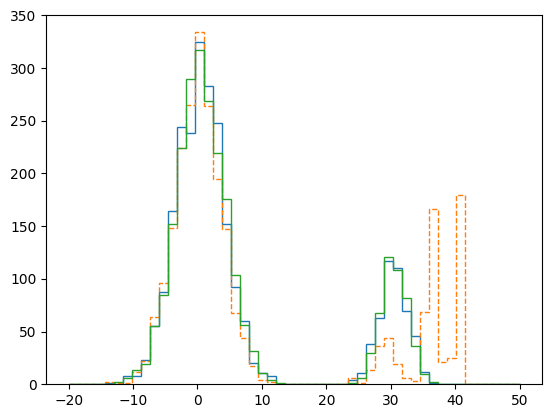

In [46]:
bins = np.linspace(-20, 50, 51)
plt.hist(yp1, bins=bins, histtype='step')
plt.hist(yp2, bins=bins, histtype='step', ls='--');
plt.hist(y_test, bins=bins, histtype='step');

# Weird distribution

In [ ]:
x = np.random.randn(10_000, 2)
x[:2000, 1] = 10.
y = 2 * x[:, 0] + 3 * x[:, 1] + 0.5 + np.random.randn(10_000)
x.shape, y.shape